## Simple MultiAI Agent Architecture

In [1]:
import os
from typing import TypedDict, Annotated, List, Literal
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import create_react_agent
from langgraph.checkpoint.memory import MemorySaver

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")

In [3]:
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

In [ ]:
## Define the state
class AgentState(MessagesState):
    next_agent:str #ehich agent should go next 

In [5]:
# Create simple tools
@tool
def search_web(query: str) -> str:
    """Search the web for information."""
    # Using Tavily for web search
    search = TavilySearchResults(max_results=3)
    results = search.invoke(query)
    return str(results)

@tool
def write_summary(content: str) -> str:
    """Write a summary of the provided content."""
    # Simple summary generation
    summary = f"Summary of findings:\n\n{content[:500]}..."
    return summary

In [6]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="qwen/qwen3-32b")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 16384, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001B75D1AE6F0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001B75D2267B0>, model_name='qwen/qwen3-32b', model_kwargs={}, groq_api_key=SecretStr('**********'))

### Example

In [8]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

# 1. The system message — sets the agent's role/behaviour
system_msg = SystemMessage(content="You are a research assistant. Use the search_web tool to find information.")

# 2. The messages list — the conversation history from state
messages = [
    HumanMessage(content="Research the use cases of agentic AI in business."),
]

# 3. What the invoke actually receives — system_msg prepended to messages
final_input = [system_msg] + messages

print(final_input)

[SystemMessage(content='You are a research assistant. Use the search_web tool to find information.', additional_kwargs={}, response_metadata={}), HumanMessage(content='Research the use cases of agentic AI in business.', additional_kwargs={}, response_metadata={})]


In [9]:
# Define agent functions (simpler approach)
def researcher_agent(state: AgentState):
    """Researcher agent that searches for information"""
    
    messages = state["messages"]
    
    # Add system message for context
    system_msg = SystemMessage(content="You are a research assistant. Use the search_web tool to find information about the user's request.")
    
    # Call LLM with tools
    researcher_llm = llm.bind_tools([search_web])
    response = researcher_llm.invoke([system_msg] + messages)
    
    # Return the response and route to writer
    return {
        "messages": [response],
        "next_agent": "writer"
    }

In [10]:
def writer_agent(state: AgentState):
    """Writer agent that creates summaries"""
    
    messages = state["messages"]
    
    # Add system message
    system_msg = SystemMessage(content="You are a technical writer. Review the conversation and create a clear, concise summary of the findings.")
    
    # Simple completion without tools
    response = llm.invoke([system_msg] + messages)
    
    return {
        "messages": [response],
        "next_agent": "end"
    }

In [11]:
# Tool executor node
def execute_tools(state: AgentState):
    """Execute any pending tool calls"""
    messages = state["messages"]
    last_message = messages[-1]
    
    # Check if there are tool calls to execute
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        # Create tool node and execute
        tool_node = ToolNode([search_web, write_summary])
        response = tool_node.invoke(state)
        return response
    
    # No tools to execute
    return state

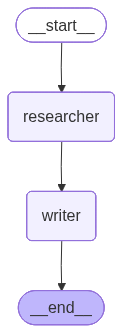

In [12]:
# Build graph
workflow = StateGraph(MessagesState)

# Add nodes
workflow.add_node("researcher", researcher_agent)
workflow.add_node("writer", writer_agent)

# Define flow
workflow.set_entry_point("researcher")
workflow.add_edge("researcher", "writer")
workflow.add_edge("writer", END)
final_workflow=workflow.compile()

final_workflow

In [18]:
response=final_workflow.invoke({"messages":"Reasearch about the usecase of agentic ai in business"})
response

{'messages': [HumanMessage(content='Reasearch about the usecase of agentic ai in business', additional_kwargs={}, response_metadata={}, id='1f684214-a03e-4ac7-97e8-e056ab099d23'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user wants me to research the use cases of agentic AI in business. Let me start by understanding what agentic AI is. From what I know, agentic AI refers to AI systems that can act autonomously or semi-autonomously, making decisions and performing tasks without constant human intervention. They might use techniques like reinforcement learning or have some level of self-directed behavior.\n\nNow, the user is asking specifically about business applications. I need to find examples where companies have implemented agentic AI. Maybe in areas like customer service, supply chain management, or personalized marketing. For instance, chatbots that handle customer inquiries are a common use case, but agentic AI might go beyond that to make more c

In [19]:
response["messages"][-1].content

"<think>\nOkay, I need to summarize the findings from the research on the use cases of agentic AI in business. The user provided a query where they asked about agentic AI use cases, and the assistant used the search_web tool to find real-world examples. Let me start by recalling what agentic AI is. Agentic AI refers to AI systems that can act autonomously, make decisions, and adapt to new situations without constant human intervention. They operate with a degree of autonomy, which makes them different from traditional AI systems that are more passive.\n\nThe search results probably covered various industries where agentic AI is applied. Common areas might include customer service, supply chain management, finance, and healthcare. Let me think through each potential use case. In customer service, chatbots and virtual assistants come to mind, but agentic AI would go beyond just answering FAQs. They might handle complex customer interactions, like escalating issues or personalizing recomm

In [21]:
# After graph runs
response = final_workflow.invoke({
    "messages": [HumanMessage(content="Research about the usecase of agentic ai in business")]
})

# Pretty print each message one by one
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

Research about the usecase of agentic ai in business
================================== Ai Message ==================================
Tool Calls:
  search_web (qetcyd4q0)
 Call ID: qetcyd4q0
  Args:
    query: agentic AI business use cases real-world applications
================================== Ai Message ==================================

<think>
Okay, the user asked about the use cases of agentic AI in business. Let me start by understanding what agentic AI means. From what I know, agentic AI refers to AI systems that can operate autonomously, make decisions, and take actions without constant human intervention. They might have goals, learn from experience, and interact with other systems or humans.

The user wants real-world examples, so I need to find specific business applications. I remember reading that autonomous vehicles use AI agents, but that's more of a tech example. Maybe in business cont

## To fix this and actually see a ToolMessage:

In [25]:
# Step 1 — add conditional edge from researcher
def should_use_tools(state):
    last = state["messages"][-1]
    if hasattr(last, "tool_calls") and last.tool_calls:
        return "tools"
    return "writer"

workflow.add_conditional_edges(
    "researcher",
    should_use_tools,
    {
        "tools": "execute_tools",  # ← route here first
        "writer": "writer"
    }
)
workflow.add_edge("execute_tools", "writer")  # ← then go to writer


Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


ValueError: Branch with name `should_use_tools` already exists for node `researcher`

In [23]:
# After graph runs
response = final_workflow.invoke({
    "messages": [HumanMessage(content="Research about the usecase of agentic ai in business")]
})

# Pretty print each message one by one
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

Research about the usecase of agentic ai in business
================================== Ai Message ==================================
Tool Calls:
  search_web (wjynzzq8j)
 Call ID: wjynzzq8j
  Args:
    query: agentic AI business use cases 2024 case studies
================================== Ai Message ==================================

<think>
Okay, I need to create a summary of the findings about the use cases of agentic AI in business. Let me start by recalling the information from the web search. The search query was "agentic AI business use cases 2024 case studies," so the results should focus on real-world applications from 2024.

First, the main points from the web results. There are a few key areas where agentic AI is being used. Healthcare is mentioned, where AI autonomously analyzes medical data and interacts with patients. That's interesting because it shows AI handling complex tasks like diag

In [27]:
# ─── IMPORTS ───────────────────────────────────────────────
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_groq import ChatGroq
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import MessagesState
from typing import Literal
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

# ─── LLM ───────────────────────────────────────────────────
llm = ChatGroq(model="llama-3.1-8b-instant")

# ─── STATE ─────────────────────────────────────────────────
class AgentState(MessagesState):
    next_agent: str  # which agent should go next

# ─── TOOLS ─────────────────────────────────────────────────
@tool
def search_web(query: str) -> str:
    """Search the web for information."""
    tavily = TavilySearchResults(max_results=3)
    return tavily.invoke(query)

@tool
def write_summary(content: str) -> str:
    """Write a summary of the provided content."""
    summary = f"Summary of findings:\n\n{content[:500]}..."
    return summary

# ─── AGENT NODES ───────────────────────────────────────────
def researcher_agent(state: AgentState):
    """Researcher agent that searches the web"""
    messages = state["messages"]
    system_msg = SystemMessage(content="""You are a research assistant. 
    Use the search_web tool to find information about the user request.""")
    
    researcher_llm = llm.bind_tools([search_web])
    response = researcher_llm.invoke([system_msg] + messages)
    
    return {
        "messages": [response],
        "next_agent": "writer"
    }

def execute_tools(state: AgentState):
    """Execute any pending tool calls"""
    messages = state["messages"]
    last_message = messages[-1]
    
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        tool_node = ToolNode([search_web, write_summary])
        response = tool_node.invoke(state)
        return response   # ← ToolMessage gets appended to state here
    
    return state

def writer_agent(state: AgentState):
    """Writer agent that creates summaries"""
    messages = state["messages"]
    system_msg = SystemMessage(content="""You are a technical writer. 
    Review the conversation and create a clear concise summary of the findings.""")
    
    response = llm.invoke([system_msg] + messages)
    
    return {
        "messages": [response],
        "next_agent": "end"
    }

# ─── ROUTER ────────────────────────────────────────────────
def should_use_tools(state: AgentState) -> Literal["tools", "writer"]:
    """Route to execute_tools if tool calls exist, else go to writer"""
    last_message = state["messages"][-1]
    
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"   # ← tool was called, go execute it
    return "writer"      # ← no tool call, go straight to writer

# ─── BUILD GRAPH ───────────────────────────────────────────
workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("researcher", researcher_agent)
workflow.add_node("execute_tools", execute_tools)
workflow.add_node("writer", writer_agent)

# Set entry point
workflow.set_entry_point("researcher")

# Add edges
workflow.add_conditional_edges(
    "researcher",
    should_use_tools,        # ← router decides next step
    {
        "tools": "execute_tools",   # ← if tool called → execute it
        "writer": "writer"          # ← if no tool → skip to writer
    }
)
workflow.add_edge("execute_tools", "writer")   # ← after tools → writer
workflow.add_edge("writer", END)               # ← after writer → done

# Compile
graph = workflow.compile()

# ─── RUN ───────────────────────────────────────────────────
response = graph.invoke({
    "messages": [HumanMessage(content="Research about the usecase of agentic ai in business")]
})

# ─── PRETTY PRINT ──────────────────────────────────────────
for message in response["messages"]:
    message.pretty_print()


C:\Users\saira\AppData\Local\Temp\ipykernel_26012\1003225358.py:28: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults(max_results=3)


================================ Human Message =================================

Research about the usecase of agentic ai in business
================================== Ai Message ==================================
Tool Calls:
  search_web (nsgfm1fhs)
 Call ID: nsgfm1fhs
  Args:
    query: agentic ai use case in business
================================= Tool Message =================================
Name: search_web

[{"title": "Agentic AI Use Cases That Prove the Power of Intelligent Automation", "url": "https://www.moveworks.com/us/en/resources/blog/agentic-ai-examples-use-cases", "content": "Table of contents\n\n## Highlights\n\n Agentic AI has rapidly evolved beyond traditional chatbots, enabling autonomous, multi-step workflow execution across enterprise systems.\n The highest-impact use cases share common traits: repetitive processes, clear policies, cross-system dependencies, and measurable business outcomes.\n Early adopters in IT, HR, finance, security, engineering, and cust

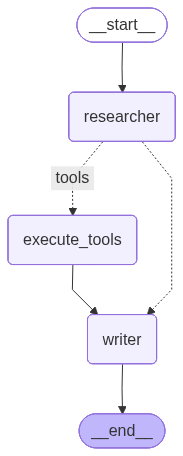

In [28]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## supervise Multi Ai Agent Architecture

In [29]:
from typing import TypedDict, Annotated, List, Literal, Dict, Any
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, END, MessagesState
from langgraph.checkpoint.memory import MemorySaver
import random
from datetime import datetime

In [30]:

# ===================================
# State Definition
# ===================================

class SupervisorState(MessagesState):
    """State for the multi-agent system"""
    next_agent: str = ""
    research_data: str = ""
    analysis: str = ""
    final_report: str = ""
    task_complete: bool = False
    current_task: str = ""

In [31]:
# ===================================
# Supervisor with Groq LLM
# ===================================
from langchain_core.prompts import ChatPromptTemplate
def create_supervisor_chain():
    """Creates the supervisor decision chain"""
    
    supervisor_prompt = ChatPromptTemplate.from_messages([
        ("system", """You are a supervisor managing a team of agents:
        
1. Researcher - Gathers information and data
2. Analyst - Analyzes data and provides insights  
3. Writer - Creates reports and summaries

Based on the current state and conversation, decide which agent should work next.
If the task is complete, respond with 'DONE'.

Current state:
- Has research data: {has_research}
- Has analysis: {has_analysis}
- Has report: {has_report}

Respond with ONLY the agent name (researcher/analyst/writer) or 'DONE'.
"""),
        ("human", "{task}")
    ])
    
    return supervisor_prompt | llm

In [32]:
def supervisor_agent(state: SupervisorState) -> Dict:
    """Supervisor decides next agent using Groq LLM"""
    
    messages = state["messages"]
    task = messages[-1].content if messages else "No task"
    
    # Check what's been completed
    has_research = bool(state.get("research_data", ""))
    has_analysis = bool(state.get("analysis", ""))
    has_report = bool(state.get("final_report", ""))
    
    # Get LLM decision
    chain = create_supervisor_chain()
    decision = chain.invoke({
        "task": task,
        "has_research": has_research,
        "has_analysis": has_analysis,
        "has_report": has_report
    })
    
    # Parse decision
    decision_text = decision.content.strip().lower()
    print(decision_text)
    
    # Determine next agent
    if "done" in decision_text or has_report:
        next_agent = "end"
        supervisor_msg = "✅ Supervisor: All tasks complete! Great work team."
    elif "researcher" in decision_text or not has_research:
        next_agent = "researcher"
        supervisor_msg = "📋 Supervisor: Let's start with research. Assigning to Researcher..."
    elif "analyst" in decision_text or (has_research and not has_analysis):
        next_agent = "analyst"
        supervisor_msg = "📋 Supervisor: Research done. Time for analysis. Assigning to Analyst..."
    elif "writer" in decision_text or (has_analysis and not has_report):
        next_agent = "writer"
        supervisor_msg = "📋 Supervisor: Analysis complete. Let's create the report. Assigning to Writer..."
    else:
        next_agent = "end"
        supervisor_msg = "✅ Supervisor: Task seems complete."
    
    return {
        "messages": [AIMessage(content=supervisor_msg)],
        "next_agent": next_agent,
        "current_task": task
    }

In [33]:
# ===================================
# Agent 1: Researcher (using Groq)
# ===================================

def researcher_agent(state: SupervisorState) -> Dict:
    """Researcher uses Groq to gather information"""
    
    task = state.get("current_task", "research topic")
    
    # Create research prompt
    research_prompt = f"""As a research specialist, provide comprehensive information about: {task}

    Include:
    1. Key facts and background
    2. Current trends or developments
    3. Important statistics or data points
    4. Notable examples or case studies
    
    Be concise but thorough."""
    
    # Get research from LLM
    research_response = llm.invoke([HumanMessage(content=research_prompt)])
    research_data = research_response.content
    
    # Create agent message
    agent_message = f"🔍 Researcher: I've completed the research on '{task}'.\n\nKey findings:\n{research_data[:500]}..."
    
    return {
        "messages": [AIMessage(content=agent_message)],
        "research_data": research_data,
        "next_agent": "supervisor"
    }

In [34]:
# ===================================
# Agent 2: Analyst (using Groq)
# ===================================

def analyst_agent(state: SupervisorState) -> Dict:
    """Analyst uses Groq to analyze the research"""
    
    research_data = state.get("research_data", "")
    task = state.get("current_task", "")
    
    # Create analysis prompt
    analysis_prompt = f"""As a data analyst, analyze this research data and provide insights:

Research Data:
{research_data}

Provide:
1. Key insights and patterns
2. Strategic implications
3. Risks and opportunities
4. Recommendations

Focus on actionable insights related to: {task}"""
    
    # Get analysis from LLM
    analysis_response = llm.invoke([HumanMessage(content=analysis_prompt)])
    analysis = analysis_response.content
    
    # Create agent message
    agent_message = f"📊 Analyst: I've completed the analysis.\n\nTop insights:\n{analysis[:400]}..."
    
    return {
        "messages": [AIMessage(content=agent_message)],
        "analysis": analysis,
        "next_agent": "supervisor"
    }

In [35]:
# ===================================
# Agent 3: Writer (using Groq)
# ===================================

def writer_agent(state: SupervisorState) -> Dict:
    """Writer uses Groq to create final report"""
    
    research_data = state.get("research_data", "")
    analysis = state.get("analysis", "")
    task = state.get("current_task", "")
    
    # Create writing prompt
    writing_prompt = f"""As a professional writer, create an executive report based on:

Task: {task}

Research Findings:
{research_data[:1000]}

Analysis:
{analysis[:1000]}

Create a well-structured report with:
1. Executive Summary
2. Key Findings  
3. Analysis & Insights
4. Recommendations
5. Conclusion

Keep it professional and concise."""
    
    # Get report from LLM
    report_response = llm.invoke([HumanMessage(content=writing_prompt)])
    report = report_response.content
    
    # Create final formatted report
    final_report = f"""
📄 FINAL REPORT
{'='*50}
Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}
Topic: {task}
{'='*50}

{report}

{'='*50}
Report compiled by Multi-Agent AI System powered by Groq
"""
    
    return {
        "messages": [AIMessage(content=f"✍️ Writer: Report complete! See below for the full document.")],
        "final_report": final_report,
        "next_agent": "supervisor",
        "task_complete": True
    }

In [36]:
# ===================================
# Router Function
# ===================================

def router(state: SupervisorState) -> Literal["supervisor", "researcher", "analyst", "writer", "__end__"]:
    """Routes to next agent based on state"""
    
    next_agent = state.get("next_agent", "supervisor")
    
    if next_agent == "end" or state.get("task_complete", False):
        return END
        
    if next_agent in ["supervisor", "researcher", "analyst", "writer"]:
        return next_agent
        
    return "supervisor"

In [37]:
# Create workflow
workflow = StateGraph(SupervisorState)

# Add nodes
workflow.add_node("supervisor", supervisor_agent)
workflow.add_node("researcher", researcher_agent)
workflow.add_node("analyst", analyst_agent)
workflow.add_node("writer", writer_agent)

# Set entry point
workflow.set_entry_point("supervisor")

# Add routing
for node in ["supervisor", "researcher", "analyst", "writer"]:
    workflow.add_conditional_edges(
        node,
        router,
        {
            "supervisor": "supervisor",
            "researcher": "researcher",
            "analyst": "analyst",
            "writer": "writer",
            END: END
        }
    )

graph=workflow.compile()
    

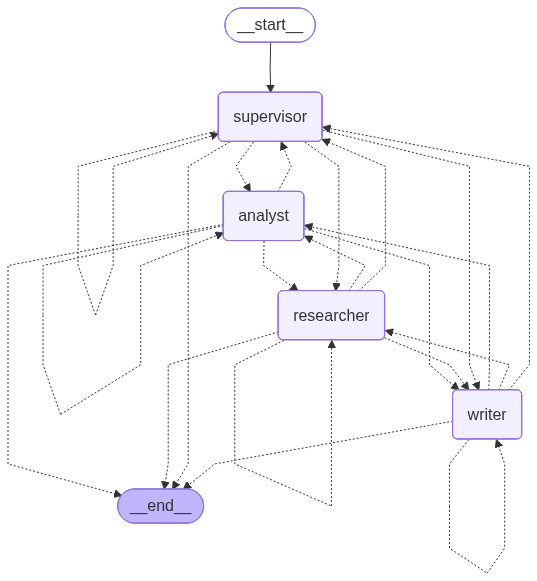

In [38]:
graph

In [39]:
response=graph.invoke(HumanMessage(content="What are the benefits and risks of AI in healthcare?"))

researcher
analyst
writer


In [40]:
response['final_report']

"\n📄 FINAL REPORT\n==================================================\nGenerated: 2026-03-24 16:17\nTopic: 📊 Analyst: I've completed the analysis.\n\nTop insights:\n**Data Analysis Insights: Vertical Farming**\n\n**1. Key Insights and Patterns:**\n\n- **Growing Demand for Sustainable Produce:** The increasing global market size of vertical farming (expected to reach $13.7 billion by 2027) indicates a growing demand for sustainable and locally grown produce.\n- **Improved Crop Yields:** Vertical farms can produce up to 30 times more crops per acre than traditional ...\n==================================================\n\n**Executive Report: Vertical Farming Market Analysis**\n\n**Executive Summary**\n\nOur analysis of the vertical farming market reveals a growing demand for sustainable and locally grown produce, driven by increasing global market size and technological advancements. Vertical farming has the potential to revolutionize food production by improving crop yields, conserving

""" Simple Hierarchical Multi-Agent System with Groq
Shows how to organize agents in teams with team leaders.

Structure:

CEO (top level)
Research Team Leader
Data Researcher
Market Researcher
Writing Team Leader
Technical Writer
Summary Writer